# Employee Attrition analysis and prediction!! WHY EMPLOYEE QUIT?


Employee attrition is one of the major challenges faced by organizations, as losing experienced employees can affect productivity, increase hiring costs, and impact overall business performance.

The goal of this project is to analyze employee-related factors and build a machine learning model capable of predicting whether an employee is likely to leave the company or stay.

This project includes:
- Exploratory Data Analysis (EDA)
- Data preprocessing
- Model training and evaluation
- Business insights related to employee attrition

# 1.Exploratory Data Analysis(EDA)
EDA helps in:
- Understanding the structure and distribution of the dataset
- Detecting missing values and duplicate records
- Identifying relationships between features
- Analyzing trends and patterns in the data
- Detecting outliers and anomalies
- Understanding class imbalance in the target variable
- Selecting important features for model building

In this project, EDA is used to analyze employee-related factors such as age, income, overtime, job role, and work environment to better understand the reasons behind employee attrition.

A proper EDA process improves data quality, supports better decision-making, and helps build more accurate and reliable machine learning models.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [4]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [5]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print("Column Name:", col)
    print("Unique Values:", df[col].unique())
    print("Number of Unique Values:", df[col].nunique())
    print("-----------------------------------")

Column Name: Attrition
Unique Values: ['Yes' 'No']
Number of Unique Values: 2
-----------------------------------
Column Name: BusinessTravel
Unique Values: ['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']
Number of Unique Values: 3
-----------------------------------
Column Name: Department
Unique Values: ['Sales' 'Research & Development' 'Human Resources']
Number of Unique Values: 3
-----------------------------------
Column Name: EducationField
Unique Values: ['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources']
Number of Unique Values: 6
-----------------------------------
Column Name: Gender
Unique Values: ['Female' 'Male']
Number of Unique Values: 2
-----------------------------------
Column Name: JobRole
Unique Values: ['Sales Executive' 'Research Scientist' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare Representative' 'Manager'
 'Sales Representative' 'Research Director' 'Human Resources']
Number of Unique Values: 9
------------

NOTE: As we analyse we can drop 'EmployeeCount' , 'over18' , 'StandardHours' as they all have one unique value and drop 'EmployeeNumber' as all values are unique.
these features aren't useful to us so drop them

In [6]:
df.drop(['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'], axis="columns", inplace=True)

# Data Visualization

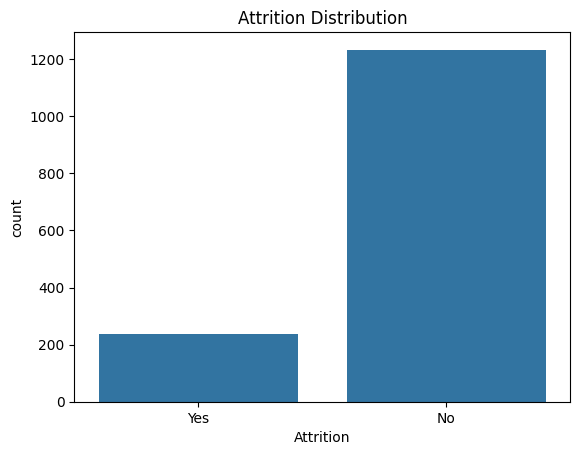

In [7]:
sns.countplot(x='Attrition', data=df)

plt.title("Attrition Distribution")
plt.show()

Clears understanding of dataset that how many employees left and not left

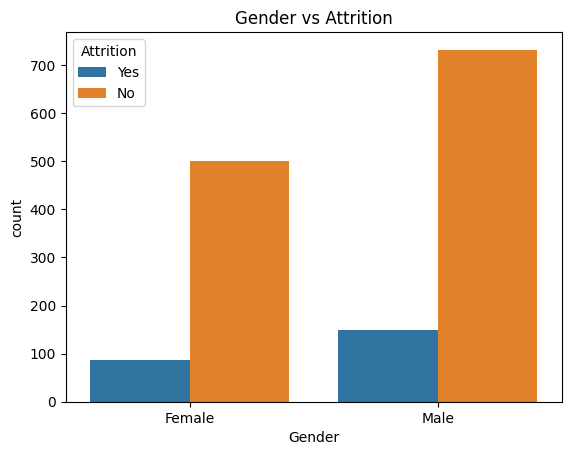

In [8]:
sns.countplot(x='Gender', hue='Attrition', data=df)

plt.title("Gender vs Attrition")
plt.show()

as we can see number of employees not left the company are significantly higher than left ones and also no of male employees not left is little higher than female ones.
so,gender feature not alone is strong factor of employee attrition.

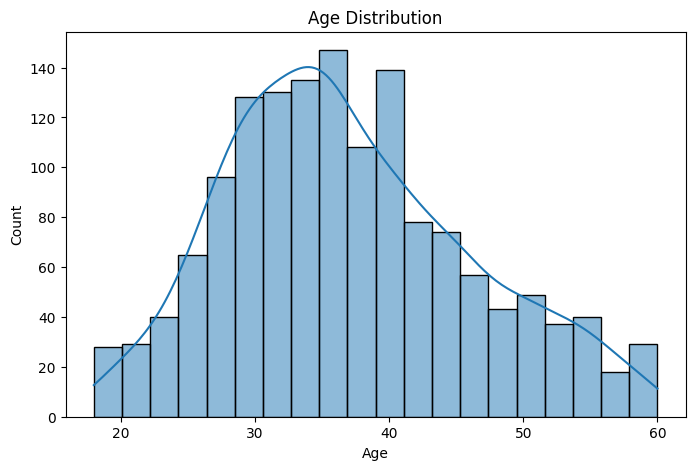

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=20, kde=True)

plt.title("Age Distribution")
plt.show()

understanding of age spread of employees.
here,most employee is of age between 30 to 40 (approx 37 age)

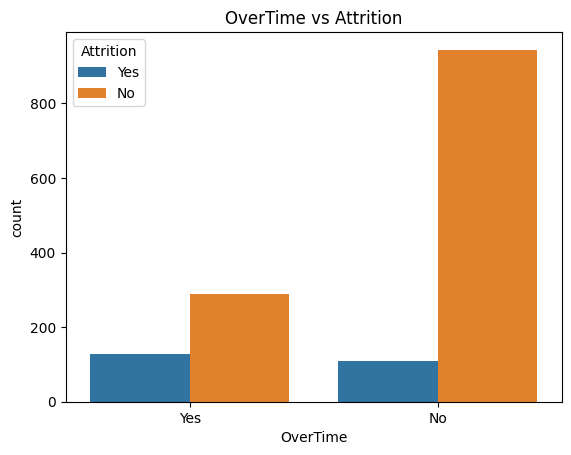

In [10]:
sns.countplot(x='OverTime', hue='Attrition', data=df)

plt.title("OverTime vs Attrition")
plt.show()

according to this, employees who work overtime have a higher attrition rate compared to employees who do not work overtime.

so, overtime may be an important factor influencing employee turnover

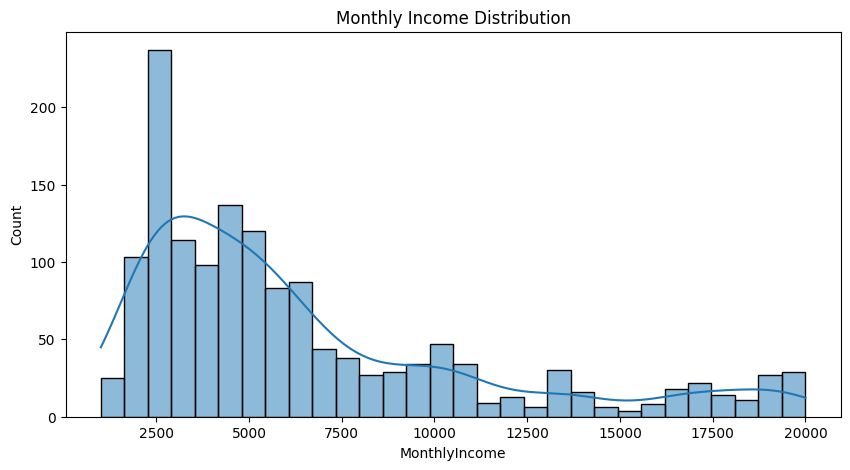

In [11]:
plt.figure(figsize=(10,5))

sns.histplot(df['MonthlyIncome'], bins=30, kde=True)

plt.title("Monthly Income Distribution")
plt.show()

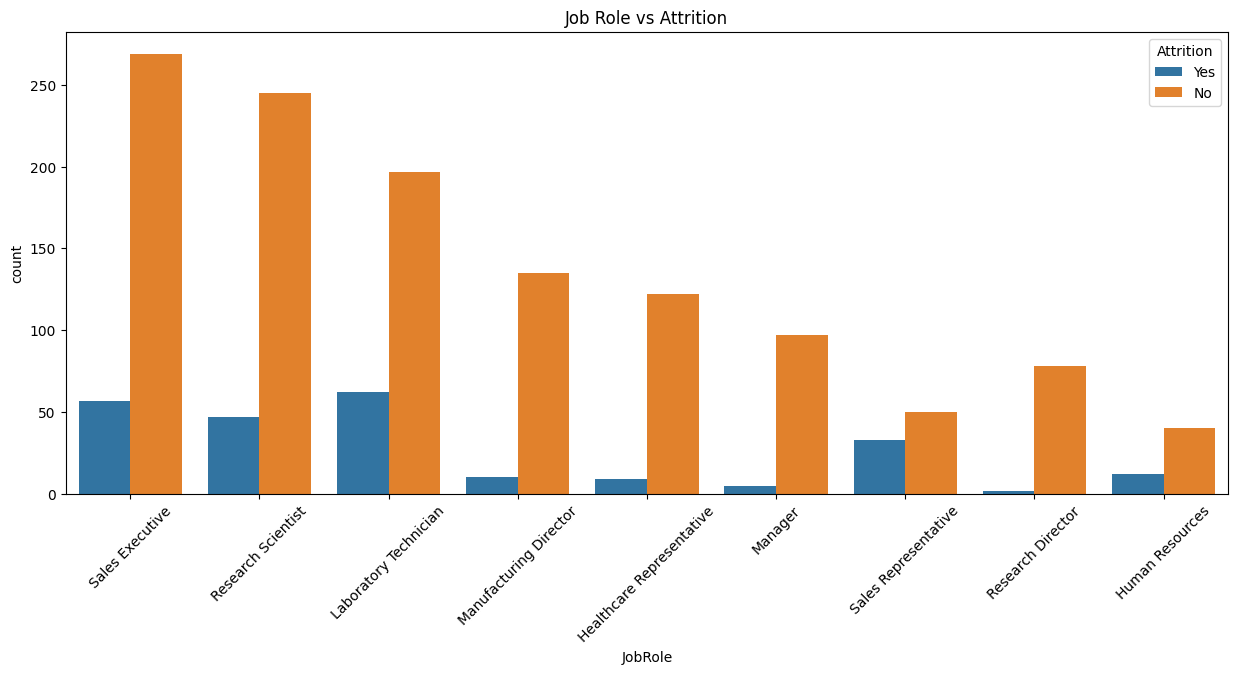

In [12]:
plt.figure(figsize=(15,6))

sns.countplot(x='JobRole', hue='Attrition', data=df)

plt.xticks(rotation=45)

plt.title("Job Role vs Attrition")
plt.show()

# Correlation Matrix

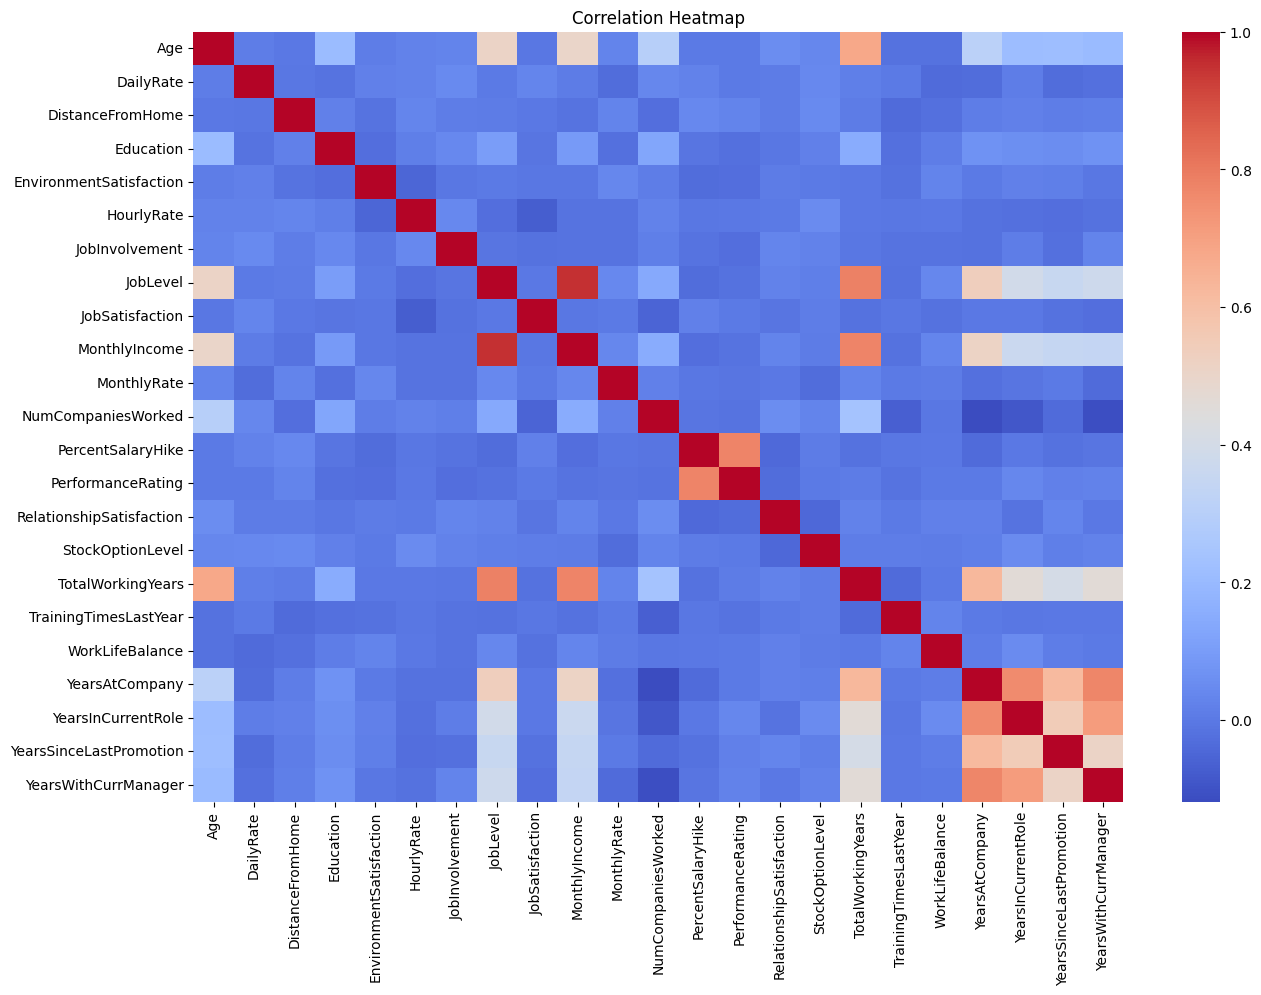

In [13]:
plt.figure(figsize=(15,10))

correlation = df.corr(numeric_only=True)

sns.heatmap(correlation, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

In [14]:
attrition_percent = df['Attrition'].value_counts(normalize=True) * 100

print(attrition_percent)

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


# # insights

1.The dataset is imbalanced, as the number of employees who did not leave the company is significantly higher than those who left.

2.Male employees show slightly higher attrition compared to female employees.

3.Employees who work overtime tend to have a higher attrition rate compared to employees who do not work overtime.

4.Most employees belong to the age group of approximately 30–40 years. The distribution is slightly right-skewed.

5.Most employees have monthly incomes concentrated in the lower to medium salary range, while only a small number of employees receive very high salaries. The distribution is positively skewed.

6.Sales Executives, Laboratory Technicians, and Research Scientists show comparatively higher attrition counts than other job roles.

7.Managers and Research Directors have lower attrition rates.

8.The heatmap shows that most features have weak correlations with each other, indicating low multicollinearity.

9.Strong positive correlations are observed between JobLevel and MonthlyIncome, as well as YearsAtCompany and YearsWithCurrManager.

# EDA Conclusion

Exploratory Data Analysis revealed that overtime, job role, income, and experience-related features have noticeable relationships with employee attrition. The dataset also contains class imbalance, which may affect model performance.

# Data Preprocessing

In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

binary_cols = ['Attrition', 'Gender', 'OverTime']

for col in binary_cols:
    df[col] = le.fit_transform(df[col])
    print(df[col])

0       1
1       0
2       1
3       0
4       0
       ..
1465    0
1466    0
1467    0
1468    0
1469    0
Name: Attrition, Length: 1470, dtype: int64
0       0
1       1
2       1
3       0
4       1
       ..
1465    1
1466    1
1467    1
1468    1
1469    1
Name: Gender, Length: 1470, dtype: int64
0       1
1       0
2       1
3       1
4       0
       ..
1465    0
1466    0
1467    1
1468    0
1469    0
Name: OverTime, Length: 1470, dtype: int64


In [16]:
x = df.drop('Attrition' , axis = 1)
y = df['Attrition']
print(x)
print(y)

      Age     BusinessTravel  DailyRate              Department  \
0      41      Travel_Rarely       1102                   Sales   
1      49  Travel_Frequently        279  Research & Development   
2      37      Travel_Rarely       1373  Research & Development   
3      33  Travel_Frequently       1392  Research & Development   
4      27      Travel_Rarely        591  Research & Development   
...   ...                ...        ...                     ...   
1465   36  Travel_Frequently        884  Research & Development   
1466   39      Travel_Rarely        613  Research & Development   
1467   27      Travel_Rarely        155  Research & Development   
1468   49  Travel_Frequently       1023                   Sales   
1469   34      Travel_Rarely        628  Research & Development   

      DistanceFromHome  Education EducationField  EnvironmentSatisfaction  \
0                    1          2  Life Sciences                        2   
1                    8          1  Life S

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
multi_col = ['BusinessTravel', 'Department',
    'EducationField',
    'JobRole',
    'MaritalStatus']
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), multi_col)], remainder='passthrough')
x = ct.fit_transform(x)
print(x)

[[0. 0. 1. ... 4. 0. 5.]
 [0. 1. 0. ... 7. 1. 7.]
 [0. 0. 1. ... 0. 0. 0.]
 ...
 [0. 0. 1. ... 2. 0. 3.]
 [0. 1. 0. ... 6. 0. 8.]
 [0. 0. 1. ... 3. 1. 2.]]


In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 1)

In [19]:
print(X_train)
print(X_test)
print(y_train)
print(y_test)

[[ 0.  0.  1. ...  3.  1.  4.]
 [ 0.  0.  1. ...  0.  0.  0.]
 [ 0.  1.  0. ...  2.  7.  7.]
 ...
 [ 0.  0.  1. ...  7.  7.  7.]
 [ 0.  0.  1. ... 13.  1.  9.]
 [ 1.  0.  0. ...  0.  0.  0.]]
[[ 0.  0.  1. ...  3.  0.  8.]
 [ 0.  1.  0. ...  0.  0.  0.]
 [ 0.  0.  1. ...  2.  0.  1.]
 ...
 [ 0.  0.  1. ... 13. 15.  2.]
 [ 0.  0.  1. ...  2.  0.  3.]
 [ 0.  1.  0. ...  1.  0.  0.]]
163     0
47      0
1085    1
98      0
942     0
       ..
715     0
905     0
1096    0
235     0
1061    0
Name: Attrition, Length: 1176, dtype: int64
1291    1
1153    1
720     1
763     0
976     0
       ..
302     0
443     1
701     0
309     0
845     0
Name: Attrition, Length: 294, dtype: int64


# Feature Scalling

In [20]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# # Logistic Regression

In [21]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(random_state = 0)
classifier.fit(X_train, y_train)

LogisticRegression(random_state=0)

In [22]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
y_pred = classifier.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print("accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

[[229   7]
 [ 37  21]]
accuracy: 0.8503401360544217
Precision: 0.75
Recall: 0.3620689655172414
F1 Score: 0.4883720930232558


-Since the dataset is slightly imbalanced, evaluation metrics such as Precision, Recall, and F1-score were used in addition to accuracy to better measure model performance.

# # Kernal SVM(Support Vector Machine)

In [23]:
from sklearn.svm import SVC
classifier = SVC(kernel = 'rbf')
classifier.fit(X_train, y_train)

SVC()

In [24]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
y_pred = classifier.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print("accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

[[235   1]
 [ 48  10]]
accuracy: 0.8333333333333334
Precision: 0.9090909090909091
Recall: 0.1724137931034483
F1 Score: 0.2898550724637681


# # KNN(K_Nearest_Neighbor)

In [25]:
from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors = 5, metric = 'minkowski', p = 2)
classifier.fit(X_train, y_train)

KNeighborsClassifier()

In [26]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
y_pred = classifier.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print("accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

[[227   9]
 [ 51   7]]
accuracy: 0.7959183673469388
Precision: 0.4375
Recall: 0.1206896551724138
F1 Score: 0.1891891891891892


# # Naive Bayes

In [27]:
from sklearn.naive_bayes import GaussianNB
classifier = GaussianNB()
classifier.fit(X_train, y_train)

GaussianNB()

In [28]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
y_pred = classifier.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print("accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

[[158  78]
 [ 22  36]]
accuracy: 0.6598639455782312
Precision: 0.3157894736842105
Recall: 0.6206896551724138
F1 Score: 0.4186046511627907


# # Random Forest Classifier

In [29]:
from sklearn.ensemble import RandomForestClassifier
classifier = RandomForestClassifier(n_estimators = 200, criterion = 'entropy', random_state=42)
classifier.fit(X_train, y_train)

RandomForestClassifier(criterion='entropy', n_estimators=200, random_state=42)

In [30]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
y_pred = classifier.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print("accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

[[233   3]
 [ 51   7]]
accuracy: 0.8163265306122449
Precision: 0.7
Recall: 0.1206896551724138
F1 Score: 0.20588235294117646


# # Decision Tree Classification

In [31]:
from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier(criterion = 'entropy', random_state = 0)
classifier.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [32]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
y_pred = classifier.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print("accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

[[205  31]
 [ 43  15]]
accuracy: 0.7482993197278912
Precision: 0.32608695652173914
Recall: 0.25862068965517243
F1 Score: 0.28846153846153844


# # Conclusion

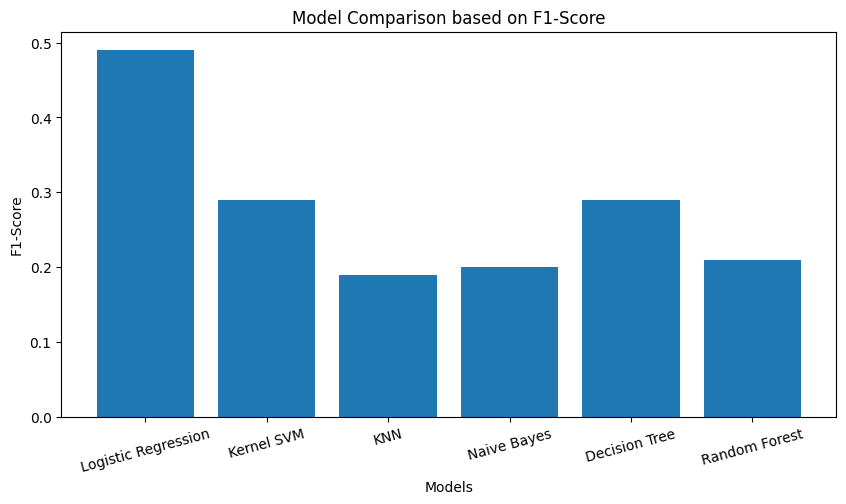

In [33]:
models = [
    'Logistic Regression',
    'Kernel SVM',
    'KNN',
    'Naive Bayes',
    'Decision Tree',
    'Random Forest'
]

f1_scores = [0.49, 0.29, 0.19, 0.20, 0.29, 0.21]

plt.figure(figsize=(10,5))

plt.bar(models, f1_scores)

plt.title("Model Comparison based on F1-Score")
plt.xlabel("Models")
plt.ylabel("F1-Score")

plt.xticks(rotation=15)

plt.show()

### Final Model Conclusion

Based on the comparison of multiple classification models, Logistic Regression achieved the best overall balance between precision, recall, F1-score, and accuracy.

Since employee attrition prediction requires identifying employees who are likely to leave the company, recall and F1-score were prioritized over accuracy alone. Therefore, **Logistic Regression** was selected as the **final model for this project**.